## orario inizio: 16:21

## finito es 0 alle 16:30

# Esercizio 3

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as st

In [24]:
cars  = pd.read_csv("data/mtcars2.txt", sep="\t", decimal=",")
cars.head()

,modello,consumo,cilindrata,peso,test400metri,trasmissione,marce,cilindri
0,Mazda RX4,21.0,110,2.620,16.46,1,4,6
1,Mazda RX4 Wag,21.0,110,2.875,17.02,1,4,6
2,Datsun 710,22.8,93,2.320,18.61,1,4,4
3,Hornet 4 Drive,21.4,110,3.215,19.44,0,3,6
4,Hornet Sportabout,18.7,175,3.440,17.02,0,3,8


In [25]:
## 3.1
len(cars)

32

<Axes: >

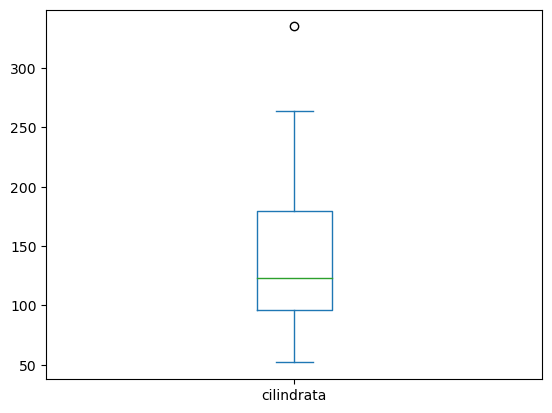

In [26]:
## 3.2
cars.cilindrata.plot.box()

In [27]:
## 3.3
grossa_cilindrata = cars[cars.cilindrata > 270]
print(len(grossa_cilindrata))
grossa_cilindrata

1


,modello,consumo,cilindrata,peso,test400metri,trasmissione,marce,cilindri
30,Maserati Bora,15.0,335,3.57,14.6,1,5,8


In [28]:
## 3.4
print(cars.cilindrata.quantile(0.25),cars.cilindrata.quantile(0.50),cars.cilindrata.quantile(0.75))

96.5 123.0 180.0


In [29]:
## 3.5
cars.cilindrata.quantile(0.75)-cars.cilindrata.quantile(0.25)

83.5

<Axes: >

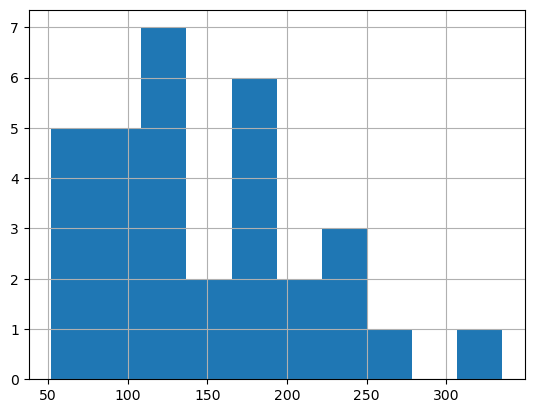

In [30]:
## 3.6
cars.cilindrata.hist()

# esercizio 4

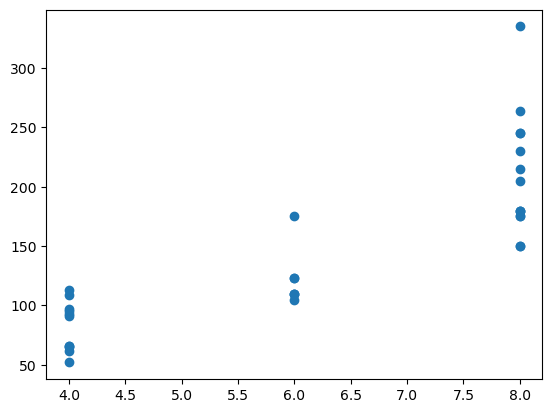

In [37]:
## 4.1
plt.scatter(cars.cilindri, cars.cilindrata)

## 4.2
sembra esserci una relazione lineare diretta tra il numero di cilindri e la cilindrata dell'auto

In [39]:
## 4.3
print(cars.cilindri.corr(cars.cilindrata)) # sembra effettivamente che ci sia una correlazione positiva molto intensa.

0.8324474527218194


# Esercizio 5

In [44]:
## 5.1
mu = cars.cilindrata.mean()
mu

146.6875

In [45]:
## 5.2
sig = cars.cilindrata.std()
sig

68.56286848932059

In [48]:
## 5.3
X = st.norm(mu, sig)

valoriSimulati = X.rvs(32)
valoriSimulati

array([193.04773766, 121.10472812, 132.27763392,  88.27526603,
       115.2517038 , 251.50610171, 123.99236224,  45.43430547,
        39.10446539,  14.75001802, 146.3362005 , 139.58687406,
       124.12009647, 102.34533169,  47.7955493 , 182.19454842,
       240.3741382 , 239.68910708,  72.29187264,  53.92504989,
       107.42614491, 122.17615535, 207.7095334 , 132.14756385,
        60.82413276, 248.59953345, 132.94078822, 154.35167087,
       280.07440702,  98.70181212,  76.78401713, 150.66986191])

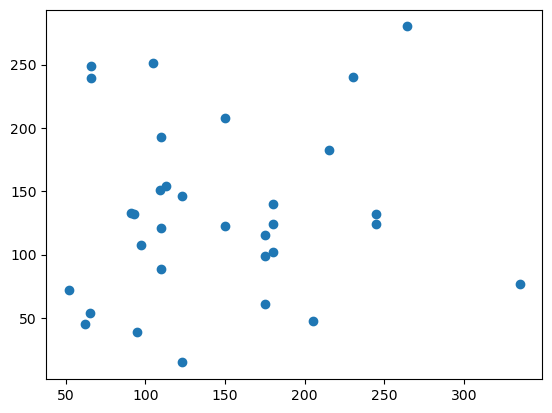

In [49]:
## 5.4
plt.scatter(cars.cilindrata, valoriSimulati)

In [51]:
## 5.5
valoriSimulatiSorted = sorted(valoriSimulati)
## 5.3
cilindrateSorted = sorted(cars.cilindrata)

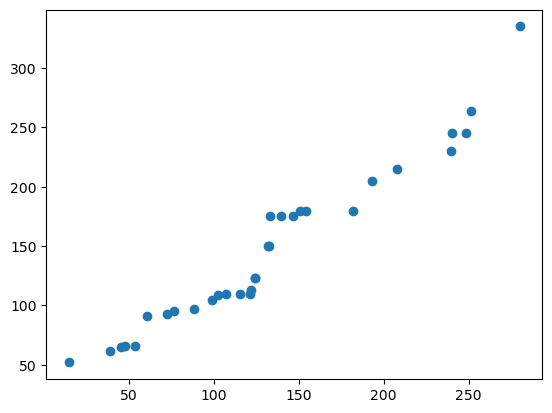

In [53]:
## 5.4
plt.scatter(valoriSimulatiSorted, cilindrateSorted)

## 5.8.I
la cilindrata segue una legge normale in quanto eseguendo un confronto quantile quantile con una distribuzione che sappiamo essere normale (quella dei valori simulati) otteniamo che sono distribuite all'incirca alla stessa maniera.
## 5.8.II
NO, in quanto andando ad analizzare lo scatter tra cilindrata e valori simulati non si ha una corrispondenza lineare evidente diretta o inversa

## 5.9
è importante in quanto il campione con cui volevamo confrontare i dati generati aveva 32 osservazioni e per poter fare un confronto quantile-quantile è necessario che i due campioni abbiano le stesse taglie

# Esercizio 6

<Axes: >

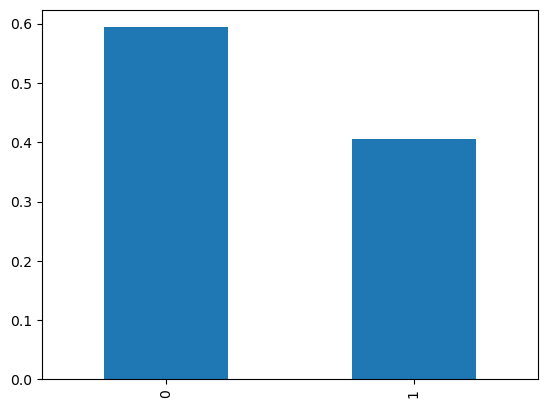

In [57]:
## 6.1
cars.trasmissione.value_counts(normalize=True).plot.bar()
# faccio un grafico a barre in quanto voglio rappresentare la distribuzione dell'attributo sui due valori che compongono
# il supporto. così facendo inoltre posso anche vedere quale attributo è più rappresentato e di quanto.

## 6.2
segue una legge bernoulliana in quanto è come se fosse l'esito binario di un esperimento.

In [59]:
## 6.3
p = cars.trasmissione.mean()
p

0.40625

## 6.4
è non distorto in quanto la media campionaria è sempre uno stimatore non distorto per il valore atteso della distribuzione

In [61]:
## 6.5
n = len(cars.trasmissione)
n

32

In [71]:
## 6.6
fr_ass = pd.crosstab(cars.trasmissione, columns=["freq Assoluta"])
fr_ass

col_0,freq Assoluta
trasmissione,
0,19
1,13


In [90]:
## 6.7
# P(X=1) = p
p # media campionaria

0.40625

## 6.8
non è distorto perchè come stimatore sto usando lo stimatore non distorto per p, la media campionaria che quindi non è distorto per p

In [91]:
## 6.9
1-p

0.59375

## 6.9
non è distorto perchè sto stimando 1-p. per stimare p sto usando la media campionaria. a questo punto calcolo $T_n = 1-Media_camp$ che non sarà distorto per 1-p e così ho calcolato uno stimatore non distorto per 1-p

In [85]:
## 6.11
z = st.norm()
sig = cars.trasmissione.std()
n_sqr = np.sqrt(n)
alfa = 0.85
z.ppf((alfa+1)/2)*sig/n_sqr

0.12698102114579055

In [ ]:
finito 17:30